In [29]:
'''
PLOT outputs from bursting_analysis.py


'''
import numpy as np
import pickle
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import seaborn as sns
from functools import reduce

In [30]:
def fill_background(df, ax, ymin = 0, ymax = 10):

    unique_peaks = sorted(df['num_peaks'].unique())
    max_peaks = max(unique_peaks) if unique_peaks else 1

    # 2. Iterate through each unique peak value to apply its specific shade
    for peak_val in unique_peaks:
        # Normalize the value to a range between 0.2 and 1.0 
        # This ensures that even 0 peaks gets a visible light green, and max peaks gets the darkest green
        norm_val = 0.2 + 0.8 * ((peak_val-1) / max_peaks) if max_peaks > 0 else 0.5
        color = plt.cm.Greys(norm_val)
        
        # 3. Fill the background for this specific value
        ax.fill_between(df['f'], ymin, ymax, 
                        where=(df['num_peaks'] == peak_val), 
                        color=color, 
                        alpha=0.3,           # Controls the overall transparency of the background
                        interpolate=True,    # Eliminates tiny white gaps between transitions
                        label=f'# ISI Peaks= {peak_val}')



In [31]:

SAVE = False
tag = 'test200'
filename = f"burst_analysis_{tag}.pickle"

with open(filename, 'rb') as file:
    df = pickle.load(file)

print(df['f'].unique())

f_vals = df['f'].unique()



[  0.          10.          14.44444444  18.88888889  23.33333333
  27.77777778  32.22222222  36.66666667  41.11111111  45.55555556
  50.          54.44444444  58.88888889  63.33333333  67.77777778
  72.22222222  76.66666667  81.11111111  85.55555556  90.
  94.44444444  98.88888889 103.33333333 107.77777778 112.22222222
 116.66666667 121.11111111 125.55555556 130.         134.44444444
 138.88888889 143.33333333 147.77777778 152.22222222 156.66666667
 161.11111111 165.55555556 170.         174.44444444 178.88888889
 183.33333333 187.77777778 192.22222222 196.66666667 201.11111111
 205.55555556 210.         214.44444444 218.88888889 223.33333333
 227.77777778 232.22222222 236.66666667 241.11111111 245.55555556
 250.         254.44444444 258.88888889 263.33333333 267.77777778
 272.22222222 276.66666667 281.11111111 285.55555556 290.
 294.44444444 298.88888889 303.33333333 307.77777778 312.22222222
 316.66666667 321.11111111 325.55555556 330.         334.44444444
 338.88888889 343.33333333

number of multi peaks in E2: 2


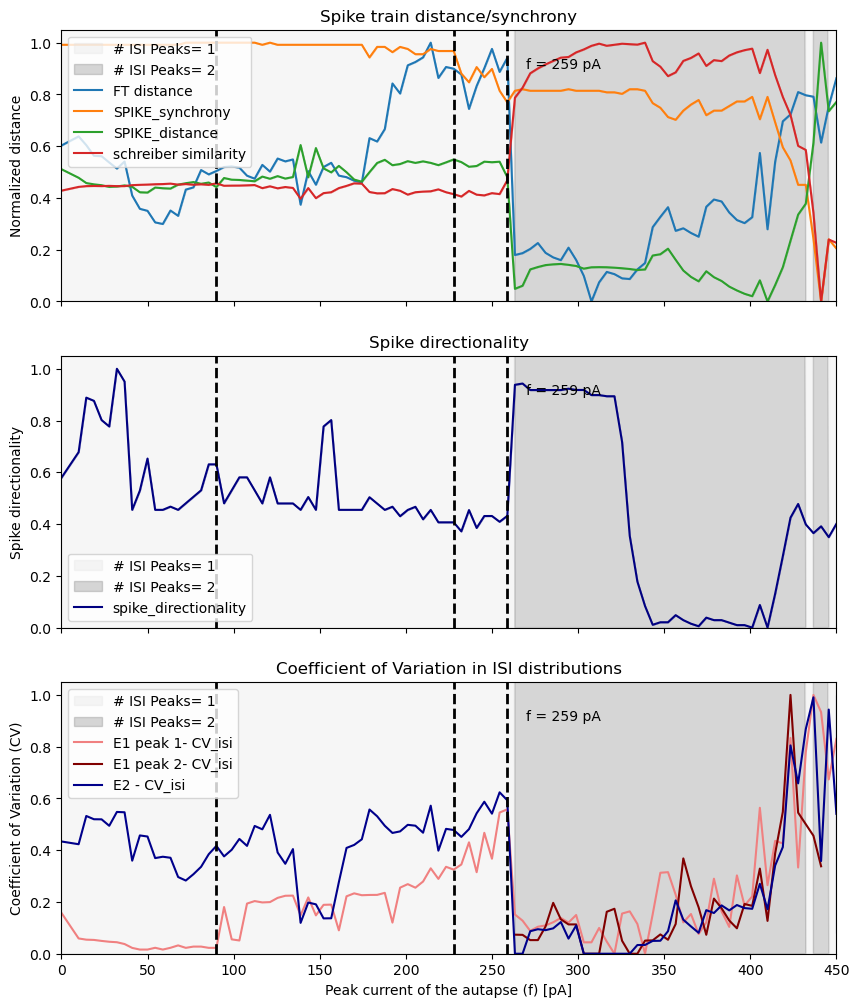

In [32]:
''' Plot one huge figure for all metrics being considered! '''

fig, ax = plt.subplots(3, 1, figsize = (10, 12), sharex = True, sharey = True)


''' AXES 0 - DISTANCE METRICS '''
E1_df = df[df['neuron_label'] == 'E1']    # num_peaks will only be relative to the autaptic neuron E1
fill_background(E1_df, ax[0])

#sns.lineplot(data = df_merged, x = 'f', y = 'num_peaks_E1', ax = ax, c = 'black', linewidth = 3)
sns.lineplot(data = df, x = 'f', 
             y = (df['FT_distance'] - df['FT_distance'].min()) / (df['FT_distance'].max() - df['FT_distance'].min()),
               ax = ax[0], label = 'FT distance')
#sns.lineplot(data = df_merged, x = 'f', 
#             y = (df_merged['FT_EMD'] - df_merged['FT_EMD'].min()) / (df_merged['FT_EMD'].max() - df_merged['FT_EMD'].min()),
#               ax = ax, label = 'FT_EMD')
sns.lineplot(data = df, x = 'f', 
             y = (df['SPIKE_synchrony'] - df['SPIKE_synchrony'].min()) / (df['SPIKE_synchrony'].max() - df['SPIKE_synchrony'].min()),
               ax = ax[0], label = 'SPIKE_synchrony')
sns.lineplot(data = df, x = 'f', 
             y = (df['SPIKE_distance'] - df['SPIKE_distance'].min()) / (df['SPIKE_distance'].max() - df['SPIKE_distance'].min()),
               ax = ax[0], label = 'SPIKE_distance')
sns.lineplot(data = df, x = 'f', 
             y = (df['schreiber similarity'] - df['schreiber similarity'].min()) / (df['schreiber similarity'].max() - df['schreiber similarity'].min()),
               ax = ax[0], label = 'schreiber similarity')

ax[0].vlines(x = [90, 228, 259], ymin = 0, ymax = 1.05, color = 'black', linestyle = '--', linewidth = 2)
ax[0].text(x = 270, y = 0.9, s = 'f = 259 pA')



''' AXES 1 - SPIKE DIRECTIONALITY '''
fill_background(E1_df, ax[1])

sns.lineplot(data = df, x = 'f', 
             y = (df['spike_directionality'] - df['spike_directionality'].min()) / (df['spike_directionality'].max() - df['spike_directionality'].min()),
               ax = ax[1], label = 'spike_directionality', color = 'navy')

ax[1].vlines(x = [90, 228, 259], ymin = 0, ymax = 1.05, color = 'black', linestyle = '--', linewidth = 2)
ax[1].text(x = 270, y = 0.9, s = 'f = 259 pA')



''' AXES 2 - CV ISI'''
fill_background(E1_df, ax[2])

peak1_df = E1_df[E1_df['peak_number'] == 1]
sns.lineplot(data = peak1_df, x = 'f', 
             y = (peak1_df['CV_isi'] - peak1_df['CV_isi'].min()) / (peak1_df['CV_isi'].max() - peak1_df['CV_isi'].min()),
                ax = ax[2], label = 'E1 peak 1- CV_isi', color = 'lightcoral')

peak2_df = E1_df[E1_df['peak_number'] == 2]
sns.lineplot(data = peak2_df, x = 'f', 
             y = (peak2_df['CV_isi'] - peak2_df['CV_isi'].min()) / (peak2_df['CV_isi'].max() - peak2_df['CV_isi'].min()),
                ax = ax[2], label = 'E1 peak 2- CV_isi', color = 'maroon')

# Plot the CV_isi for the E2 peak
E2_df = df[df['neuron_label'] == 'E2']
print(f"number of multi peaks in E2: {len(E2_df[E2_df['num_peaks'] > 1])}")
sns.lineplot(data = E2_df, x = 'f', 
             y = (E2_df['CV_isi'] - E2_df['CV_isi'].min()) / (E2_df['CV_isi'].max() - E2_df['CV_isi'].min()),
                ax = ax[2], label = 'E2 - CV_isi', color = 'darkblue')

ax[2].vlines(x = [90, 228, 259], ymin = 0, ymax = 1.05, color = 'black', linestyle = '--', linewidth = 2)
ax[2].text(x = 270, y = 0.9, s = 'f = 259 pA')

# set axes limits...
ax[2].set_ylim((0, 1.05))
ax[2].set_xlim((np.min(f_vals), np.max(f_vals)))

#set axes labels and titles...
ax[0].set_title('Spike train distance/synchrony')
ax[1].set_title('Spike directionality')
ax[2].set_title('Coefficient of Variation in ISI distributions')

ax[0].set_ylabel('Normalized distance')
ax[1].set_ylabel('Spike directionality')
ax[2].set_ylabel('Coefficient of Variation (CV)')

ax[2].set_xlabel('Peak current of the autapse (f) [pA]')

if SAVE: plt.savefig(f'plots//metrics_versus_f_{tag}.png')


In [33]:
def plot_colored_series(t, data, f, cmap_name='viridis'):
    """
    Plots multiple time series colored by an auxiliary array f.
    
    Parameters:
    t (1D array): Time steps of length M.
    data (2D array): Shape (N, M), where N is the number of series.
    f (1D/2D array): Values of length N used for coloring.
    cmap_name (str): Matplotlib colormap name.
    """
    n_series, n_points = data.shape
    
    # 1. Create segments for LineCollection
    # Each segment is ( (x0, y0), (x1, y1), ... (xM, yM) )
    segments = [np.column_stack([t, data[i, :]]) for i in range(n_series)]
    
    # 2. Normalize f values to [0, 1] for the colormap
    f_values = np.asarray(f).flatten()
    norm = plt.Normalize(f_values.min(), f_values.max())
    
    # 3. Create the collection
    lc = LineCollection(segments, cmap=cmap_name, norm=norm)
    lc.set_array(f_values)
    lc.set_linewidth(1.5)
    lc.set_alpha(0.7)  # Slight transparency for overlapping lines
    
    # 4. Plotting
    fig, ax = plt.subplots(figsize=(10, 6))
    line = ax.add_collection(lc)
    
    # Auto-scale axes (LineCollection doesn't do this automatically)
    ax.set_xlim(t.min(), t.max())
    ax.set_ylim(data.min(), data.max())
    
    # Add colorbar
    cbar = fig.colorbar(line, ax=ax)
    cbar.set_label('f-array values')
    
    ax.set_xlabel('Time')
    ax.set_ylabel('Value')
    ax.set_title('Time Series Colored by Auxiliary Data')
    
    plt.show()

dict_keys(['e', 'f', 'tau', 'time', 'X_E1', 'X_E2', 'I_E1', 'I_E2', 'spikes_E1', 'spikes_E2'])
50000
F_100 = 98.88888888888889
F_250 = 250.0
F_272 = 272.22222222222223
F_350 = 347.77777777777777
F_445 = 445.5555555555556


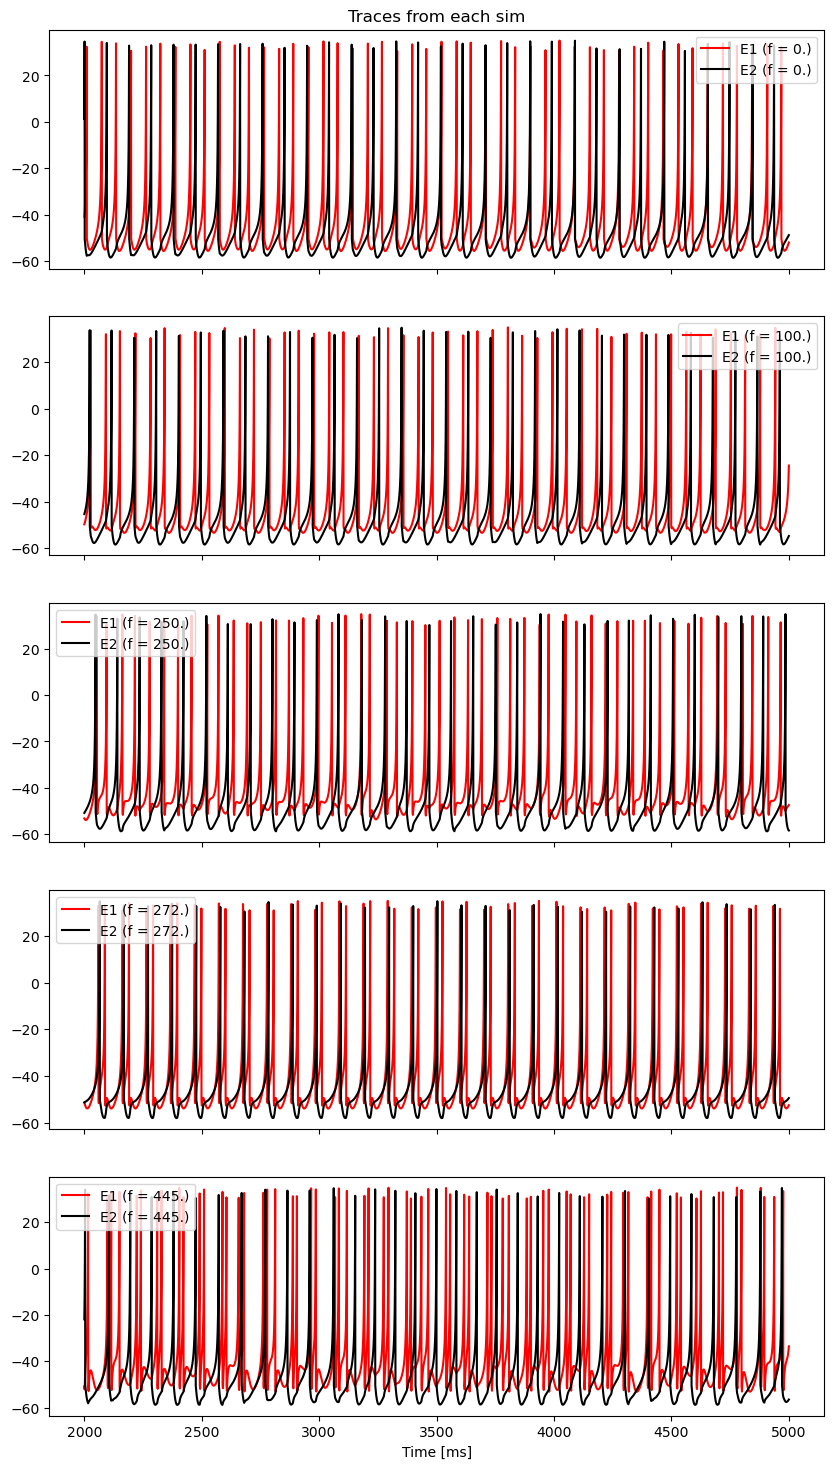

In [34]:
## OPEN AND PLOT THE TRACE DATA
trace_file = filename[:-7] + 'TRACES' + filename[-7:]
with open(trace_file, 'rb') as file:
    traces = pickle.load(file)

print(traces.keys())

f = traces['f']
time = traces['time']
X_E1 = traces['X_E1']
X_E2 = traces['X_E2']

N_iter = np.shape(time)[0]
print(N_iter)

idx0 = np.argmin(np.abs(f - 0.))
X_v1_0 = X_E1[idx0, :]
X_v2_0 = X_E2[idx0, :]

idx_100 = np.argmin(np.abs(f - 100.))
print(f'F_100 = {f[idx_100]}')
X_v1_100 = X_E1[idx_100, :]
X_v2_100 = X_E2[idx_100, :]

idx_250 = np.argmin(np.abs(f - 250.))
print(f'F_250 = {f[idx_250]}')
X_v1_250 = X_E1[idx_250, :]
X_v2_250 = X_E2[idx_250, :]

idx_272 = np.argmin(np.abs(f - 272.))
print(f'F_272 = {f[idx_272]}')
X_v1_272 = X_E1[idx_272, :]
X_v2_272 = X_E2[idx_272, :]

idx_350 = np.argmin(np.abs(f - 350.))
print(f'F_350 = {f[idx_350]}')
X_v1_350 = X_E1[idx_350, :]
X_v2_350 = X_E2[idx_350, :]

idx_445 = np.argmin(np.abs(f - 445.))
print(f'F_445 = {f[idx_445]}')
X_v1_445 = X_E1[idx_445, :]
X_v2_445 = X_E2[idx_445, :]

fig, ax = plt.subplots(5, 1, figsize = (10, 18), sharex = True)
split = np.arange(20000, 50000)

ax[0].set_title('Traces from each sim')
ax[0].plot(time[split], X_v1_0[split], c = 'red', label = f'E1 (f = 0.)')
ax[0].plot(time[split], X_v2_0[split], c = 'black', label = f'E2 (f = 0.)')
ax[0].legend()

ax[1].plot(time[split], X_v1_100[split], c = 'red', label = f'E1 (f = 100.)')
ax[1].plot(time[split], X_v2_100[split], c = 'black', label = f'E2 (f = 100.)')
ax[1].legend()

ax[2].plot(time[split], X_v1_250[split], c = 'red', label = f'E1 (f = 250.)')
ax[2].plot(time[split], X_v2_250[split], c = 'black', label = f'E2 (f = 250.)')
ax[2].legend()

ax[3].plot(time[split], X_v1_272[split], c = 'red', label = f'E1 (f = 272.)')
ax[3].plot(time[split], X_v2_272[split], c = 'black', label = f'E2 (f = 272.)')
ax[3].legend()

ax[4].plot(time[split], X_v1_445[split], c = 'red', label = f'E1 (f = 445.)')
ax[4].plot(time[split], X_v2_445[split], c = 'black', label = f'E2 (f = 445.)')
ax[4].legend()

ax[4].set_xlabel('Time [ms]')


if SAVE: plt.savefig(f'plots/traces_per_sim_{tag}.png')

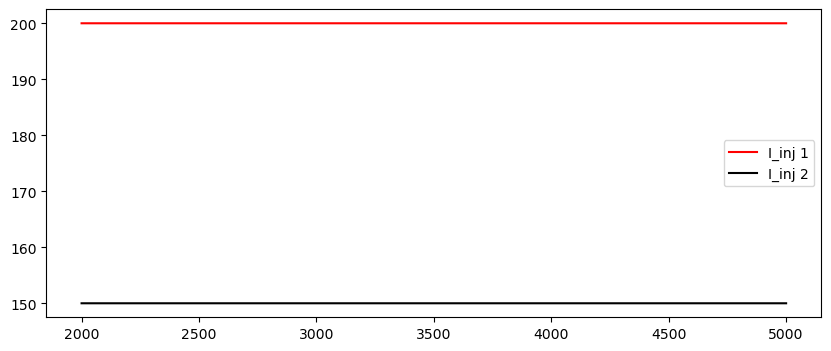

In [35]:
fig, ax = plt.subplots(1, 1, figsize = (10, 4))

I_inj1 = traces['I_E1'][0, :]
I_inj2 = traces['I_E2'][0, :]

ax.plot(time[split], I_inj1[split], c = 'red', label = 'I_inj 1')
ax.plot(time[split], I_inj2[split], c = 'black', label = 'I_inj 2')
ax.legend()
